# Sistema y simulación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from numba import njit

@njit(fastmath=True)
def getMaxRealPart(N, C_range, n_average, sigma_n_range, sigma_ln_range):
    # Dimensiones de los rangos
    n_connect = C_range.shape[0]
    n_sn = sigma_n_range.shape[0]
    n_sln = sigma_ln_range.shape[0]
    
    # El resultado final es un array 3D: (conectividad, sigma_n, sigma_ln)
    list_eigvals_avg = np.zeros((n_connect, n_sn, n_sln), dtype=np.float64)
    
    # Pre-calculamos N_c para evitar operaciones repetitivas
    N_c_list = (N * N * C_range).astype(np.int64)

    # Bucle 1: Conectividad
    for i in range(n_connect):
        N_c = N_c_list[i]
        
        # Bucle 2: Rango de Sigma N
        for j in range(n_sn):
            sn = sigma_n_range[j]
            
            # Bucle 3: Rango de Sigma Log-Normal
            for k in range(n_sln):
                sln = sigma_ln_range[k]
                
                # Acumulador para el promedio de n_average
                sum_max_re = 0.0
                
                # Bucle 4: Promedio estadístico (Monte Carlo)
                for t in range(n_average):
                    A = np.zeros((N, N))
                    
                    # Poblamos la matriz A
                    indices = np.random.permutation(N * N)[:N_c]
                    for idx in indices:
                        row = idx // N
                        col = idx % N
                        A[row, col] = np.random.normal(0, sn)

                    # Generamos K y ajustamos diagonal de A
                    K = np.random.lognormal(0, sln, N)
                    for diag_idx in range(N):
                        A[diag_idx, diag_idx] = -1.0 / K[diag_idx]

                    # Calculamos el Jacobiano J
                    J = np.zeros((N, N))
                    for r in range(N):
                        row_sum = 0.0
                        for c in range(N):
                            val = A[r, c] * K[c]
                            J[r, c] = val
                            row_sum += val
                        # La diagonal de J es la suma de la fila de A_ij * K_j
                        J[r, r] = row_sum

                    # Calculamos autovalores y buscamos la parte real máxima
                    vals = np.linalg.eigvals(J.astype(np.complex128))
                    
                    max_re = -1e15 
                    for v in vals:
                        if v.real > max_re:
                            max_re = v.real
                    
                    sum_max_re += max_re
                
                # Guardamos el promedio en la celda correspondiente
                list_eigvals_avg[i, j, k] = sum_max_re / n_average
        
    return list_eigvals_avg

@njit(fastmath=True)
def drift(x, tau, K):
    return x/tau * (1 - x/K)

@njit(fastmath=True)
def diffusion(x, tau, sigma, epsilon):
    return x * sigma/tau * epsilon

@njit(fastmath=True)
def time_series(x_0, steps, dt, params):
    tau, K, sigma = params
    x = np.zeros(steps)
    x[0] = x_0[0]
    epsilon = np.random.standard_normal(steps)

    for i in range(1, steps):
        # Primero calculamos el término predictor del algoritmo de Heun
        drift_predictor = drift(x[i-1], tau, K)
        diffusion_predictor = diffusion(x[i-1], tau, sigma, epsilon[i-1])
        x_pred = x[i-1] + dt * drift_predictor + np.sqrt(dt) * diffusion_predictor

        # Y ahora el corrector
        drift_corrector = drift(x_pred, tau, K)
        diffusion_corrector = diffusion(x_pred, tau, sigma, epsilon[i-1])

        # Y finalmente promediamos las dos
        x[i] = x[i-1] + dt * 0.5 * (drift_predictor + drift_corrector) + np.sqrt(dt) * 0.5 * (diffusion_predictor + diffusion_corrector)

    return x

@njit
def samples(x_0, steps, dt, params):
    tau, K, sigma = params
    N = np.shape(x_0)[0]
    x = x_0

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)
        # Primero calculamos el término predictor del algoritmo de Heun
        drift_predictor = drift(x, tau, K)
        diffusion_predictor = diffusion(x, tau, sigma, epsilon)
        x_pred = x + dt * drift_predictor + np.sqrt(dt) * diffusion_predictor

        # Y ahora el corrector
        drift_corrector = drift(x_pred, tau, K)
        diffusion_corrector = diffusion(x_pred, tau, sigma, epsilon)

        # Y finalmente promediamos las dos
        x += dt * 0.5 * (drift_predictor + drift_corrector) + np.sqrt(dt) * 0.5 * (diffusion_predictor + diffusion_corrector)


    return x

@njit(fastmath=True)
def interacting_time_series(x_0, sigma, tau, dt, A, steps):
    N_species = x_0.shape[0]
    int_time_series = np.zeros((steps, N_species))
    int_time_series[0] = x_0
    for i in range(1, steps):
        drift = int_time_series[i-1] / tau * (1 + A @ int_time_series[i-1])
        diffusion = int_time_series[i-1] * sigma * np.random.standard_normal(N_species)
        int_time_series[i] = int_time_series[i-1] + dt * drift + np.sqrt(dt) * diffusion
    
    return int_time_series

@njit(fastmath=True)
def drift(x, tau, K):
    return x/tau * (1 - x/K)

@njit(fastmath=True)
def diffusion(x, tau, sigma, epsilon):
    return x * sigma/tau * epsilon

@njit(fastmath=True)
def third_law(x_0, steps, dt, params):
    tau, K_range, sigma = params
    N = np.shape(x_0)[0]
    x = x_0

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)
        for j in range(N):

            # Y finalmente promediamos las dos
            x[j] += dt *drift(x[j], tau, K_range[j]) + np.sqrt(dt) * diffusion(x[j], tau, sigma, epsilon[i])

    return x

## Primera ley

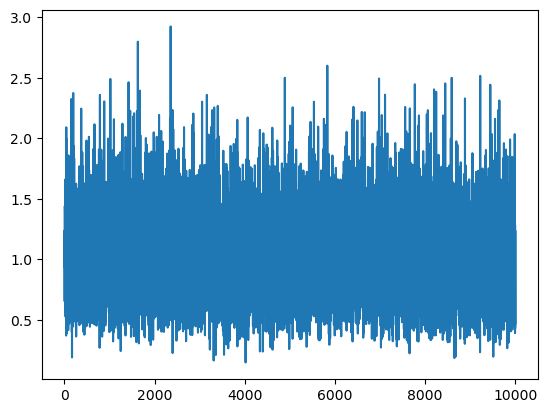

mu:  0.9984598224425237
std:  0.3526355102257869


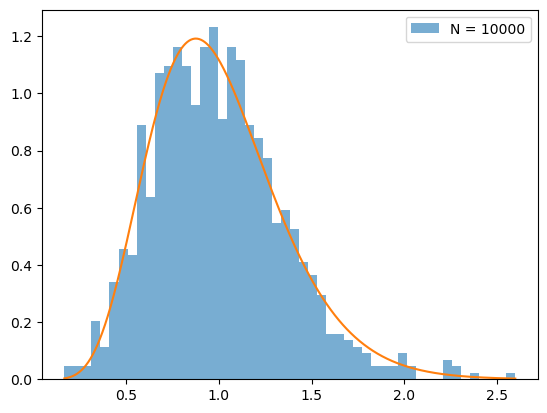

In [17]:
N = 10000
x_0 = np.ones(N)
steps = 10000
dt = 0.01
tau = 4.0
K = 1.0
sigma = 1
params = (tau, K, sigma)
alpha = 2 * tau / sigma**2 
beta = 2 * tau / (K * sigma**2)

x = samples(x_0, steps, dt, params)
plt.plot(x)
plt.show()

mu = x.mean()
std = x.std()
print("mu: ", mu)
print("std: ", std)

_, bins, _ = plt.hist(x[1000::10], bins=50, density=True, alpha=0.6, label=f"N = {N}")

x_range = np.linspace(bins.min(), bins.max(), 1000)

gamma = beta**alpha / sc.special.gamma(alpha) * x_range ** (alpha-1) * np.exp(-x_range * beta)
plt.plot(x_range, gamma)
plt.legend()

plt.show()

## Segunda ley

Ejecutado paso  0
Ejecutado paso  1
Ejecutado paso  2
Ejecutado paso  3
Ejecutado paso  4
Ejecutado paso  5
Ejecutado paso  6
Ejecutado paso  7
Ejecutado paso  8
Ejecutado paso  9
Ejecutado paso  10
Ejecutado paso  11
Ejecutado paso  12
Ejecutado paso  13
Ejecutado paso  14
Ejecutado paso  15
Ejecutado paso  16
Ejecutado paso  17
Ejecutado paso  18
Ejecutado paso  19
Ejecutado paso  20
Ejecutado paso  21
Ejecutado paso  22
Ejecutado paso  23
Ejecutado paso  24
Ejecutado paso  25
Ejecutado paso  26
Ejecutado paso  27
Ejecutado paso  28
Ejecutado paso  29
Ejecutado paso  30
Ejecutado paso  31
Ejecutado paso  32
Ejecutado paso  33
Ejecutado paso  34
Ejecutado paso  35
Ejecutado paso  36
Ejecutado paso  37
Ejecutado paso  38
Ejecutado paso  39
Ejecutado paso  40
Ejecutado paso  41
Ejecutado paso  42
Ejecutado paso  43
Ejecutado paso  44
Ejecutado paso  45
Ejecutado paso  46
Ejecutado paso  47
Ejecutado paso  48
Ejecutado paso  49
Ejecutado paso  50
Ejecutado paso  51
Ejecutado paso  52
Eje

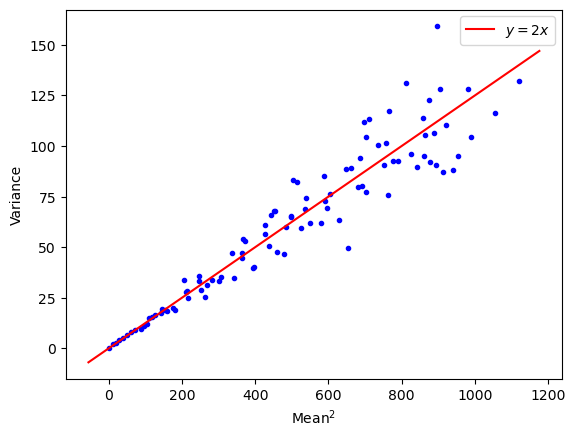

In [8]:
tau_range = 1 / np.linspace(2, 0.1, 100)
K_range = np.sqrt(np.linspace(1, 1000, 100))
sigma_range = np.sqrt(np.linspace(0, 3, 100))

N = 100
x_0 = np.ones(N)
steps = 5000
dt = 0.01
tau = 4
K = 1
sigma = 1

# Variando tau
variable = K_range
mean = np.zeros(len(variable))
var = np.zeros(len(variable))

for i in range(len(variable)):
    params = (tau, variable[i], sigma)
    x = samples(x_0, steps, dt, params)
    mean[i] = x.mean()
    var[i] = x.var()
    print("Ejecutado paso ", i)

plt.plot(mean**2, var, 'b.')
plt.xlabel(r"Mean$^2$")
plt.ylabel("Variance")
x_lim = plt.gca().get_xlim()
x_range = np.linspace(x_lim[0], x_lim[1], 100)
y_range = sigma / (2 * tau) * x_range
plt.plot(x_range, y_range, 'r', label=r"$y = 2x$")
plt.legend()


## Tercera ley

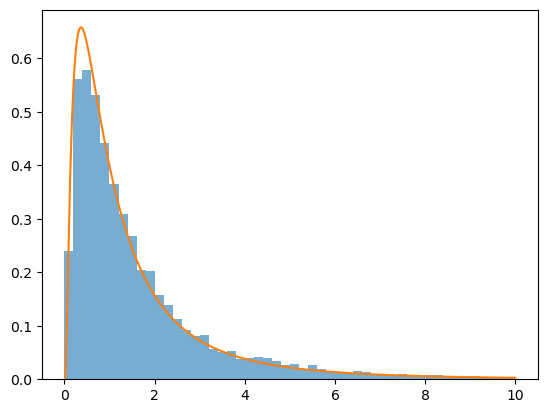

In [ ]:
N = 10000
K_range = np.random.lognormal(mean=0, sigma=1, size=N)
x_0 = np.ones(N)
steps = 3000
dt = 0.1
tau = 4
sigma = 1

x = third_law(x_0, steps, dt, (tau, K_range, sigma))

_, bins, _  = plt.hist(x, bins=50, density=True, alpha=0.6, label=f"N = {N}", range=[0, 10])

x_range = np.linspace(0.01, 10, 1000)

loc = 0
scale = 1
lognormal = sc.stats.lognorm.pdf(x_range, 1)
plt.plot(x_range, lognormal)


## Paper de Miguel Ángel

N_c:  50
K_max:  9.34794603661502


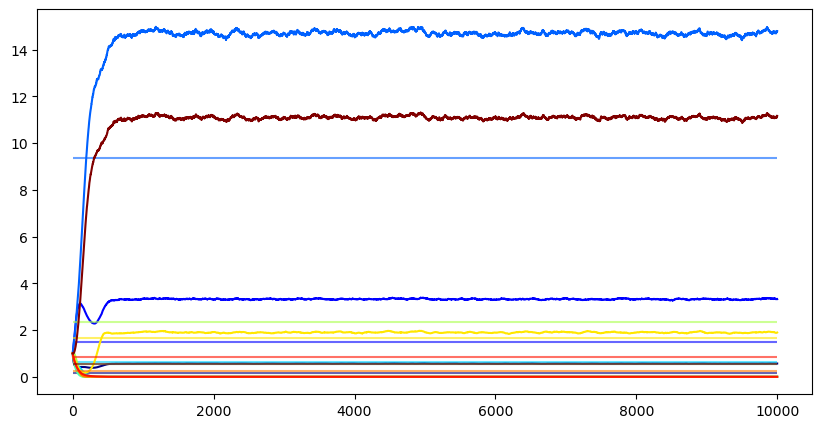

In [ ]:
N = 10
dt = 0.01
total_time = 100
steps = int(total_time/dt)
K_range = np.random.lognormal(size=N)
x_0 = np.ones(N)
sigma = 0.01
tau = 1

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K_range.max()**2))
C = 0.5
N_c = int(N * N * C)
print("N_c: ", N_c)
print("K_max: ", K_range.max())
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.standard_normal(N_c)
np.fill_diagonal(A, -1 / K_range)


t_series = interacting_time_series(x_0, sigma, tau, dt, A, steps)

# plt.hist(t_series[-1], bins=30, density=True, alpha=0.8)

# Colores
cmap = plt.get_cmap('jet')
valores = np.linspace(0, 1, N)
lista_colores = [cmap(v) for v in valores]

for i in range(N):
    plt.hlines(K_range[i], xmin=0, xmax=steps, alpha=0.6, color=lista_colores[i])
    plt.plot(t_series[:, i], color=lista_colores[i])

plt.gcf().set_size_inches(10, 5)
plt.show()



## Jacobian and stablity
### Spectrum of the Jacobian

N_c:  1000


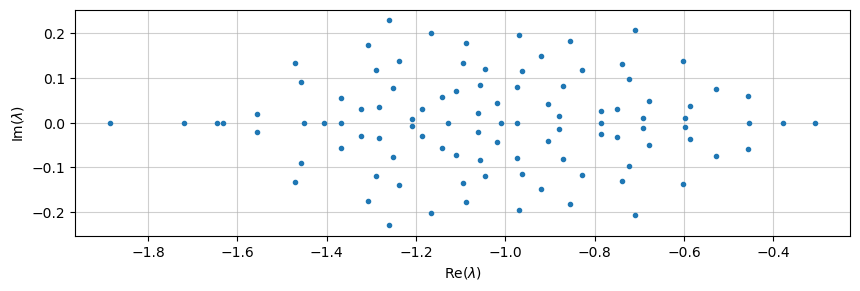

In [ ]:
N = 100

# Generamos la matriz de conexiones según la conectividad C

C = 0.1
sigma_n = 0.1
sigma_ln = 0.1
N_c = int(N * N * C)
print("N_c: ", N_c)
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.normal(scale=sigma_n, size=N_c)

K = np.random.lognormal(sigma=sigma_ln, size=N)
np.fill_diagonal(A, -1/K)

# Calculamos el Jacobiano
diagonal = A @ K 
J = A * K[:, None]
np.fill_diagonal(J, diagonal)

# Calculamos los autovalores
eigenvalues = np.linalg.eigvals(J)
plt.plot(eigenvalues.real, eigenvalues.imag, marker='.', linestyle='')
plt.grid(True, alpha=0.6)
plt.xlabel(r"Re($\lambda$)")
plt.ylabel(r"Im($\lambda$)") 
plt.gca().set_aspect('equal')
plt.gcf().set_figwidth(10)
plt.show()

### Stability and conectivity

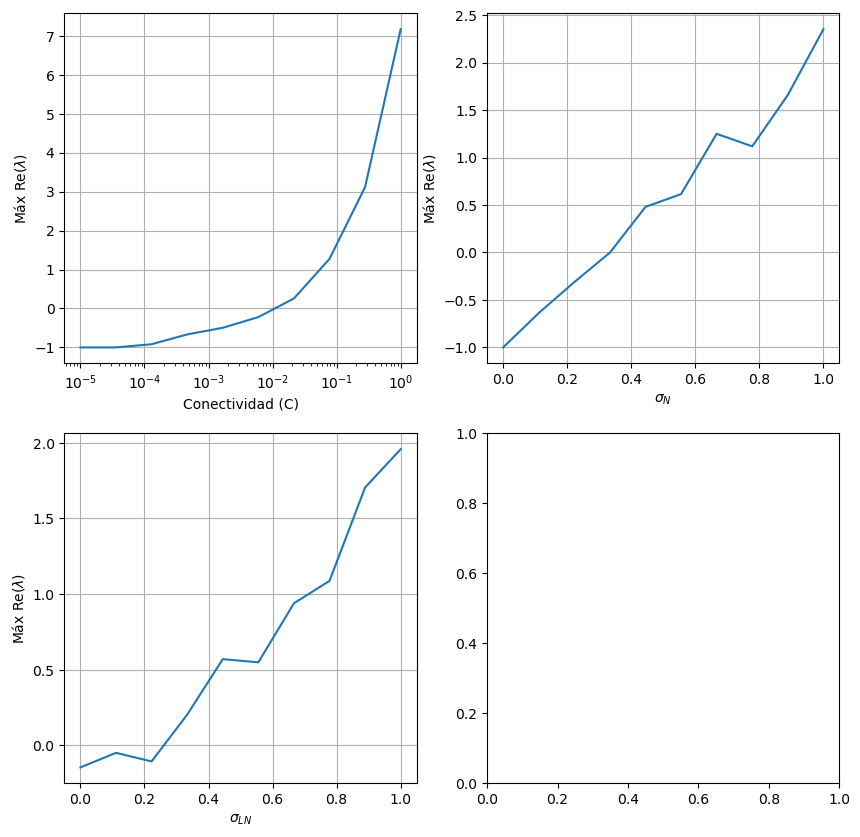

In [ ]:
# --- Ejecución ---
N = 100
C_range = np.logspace(-5, 0, 10)
sigma_n_range = np.linspace(0, 1, 10)
sigma_ln_range = np.linspace(0, 1, 10)

single_C = np.array([0.01])
single_sigma_n = np.array([0.3])
single_sigma_ln = np.array([0.03])
n_average = 10

varying_connections = getMaxRealPart(N, C_range, n_average, single_sigma_n, single_sigma_ln)
varying_sigma_n = getMaxRealPart(N, single_C, n_average, sigma_n_range, single_sigma_ln)
varying_sigma_ln = getMaxRealPart(N, single_C, n_average, single_sigma_n, sigma_ln_range)

# list_max_real_part.shape = (n_connect, n_sn, n_sln)
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))

# Plot variando C
ax[0, 0].plot(C_range, varying_connections[:, 0, 0])
ax[0, 0].set_xlabel("Conectividad (C)")
ax[0, 0].set_ylabel(r"Máx Re($\lambda$)")
ax[0, 0].grid(True)

# Plot variando sigma_n
ax[0, 1].plot(sigma_n_range, varying_sigma_n[0, :, 0])
ax[0, 1].set_xlabel(r"$\sigma_N$")
ax[0, 1].set_ylabel(r"Máx Re($\lambda$)")
ax[0, 1].grid(True)

# Plot variando sigma_ln
ax[1, 0].plot(sigma_ln_range, varying_sigma_ln[0, 0, :])
ax[1, 0].set_xlabel(r"$\sigma_{LN}$")
ax[1, 0].set_ylabel(r"Máx Re($\lambda$)")
ax[1, 0].grid(True)


plt.show()

## Correlation and connectivity

In [ ]:
N = 10
dt = 0.01
total_time = 100
steps = int(total_time/dt)
K_range = np.random.lognormal(size=N)
x_0 = np.ones(N)
sigma = 0.01
tau = 1

# Creación de la matriz A
N_c = int(N * 0.001/(sigma**2 * K_range.max()**2))
C = 0.5
N_c = int(N * N * C)
print("N_c: ", N_c)
print("K_max: ", K_range.max())
A = np.zeros((N, N))

flat_indices = np.arange(N*N)
selected_indices = np.random.choice(flat_indices, N_c, False)
rows, columns = np.unravel_index(selected_indices, (N, N))
A[rows, columns] = np.random.standard_normal(N_c)
np.fill_diagonal(A, -1 / K_range)


t_series = interacting_time_series(x_0, sigma, tau, dt, A, steps)
